In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

In [ ]:
test = pkl.load('/playagain_pipeline/data/models/svm_20260204_123517/scaler.pkl')

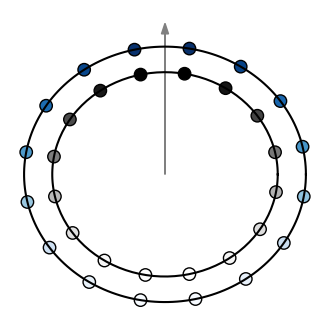

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
N = 16
theta_rot = np.deg2rad(35)      # rotation angle
tilt = np.deg2rad(25)           # bracelet tilt
r_inner = 0.8
r_outer = 1.0

theta = np.linspace(0, 2*np.pi, N, endpoint=False) + theta_rot

def project_ring(r):
    # 3D circle
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.zeros_like(x)

    # rotate around x-axis (tilt)
    y_t = y * np.cos(tilt) - z * np.sin(tilt)
    z_t = y * np.sin(tilt) + z * np.cos(tilt)

    return x, y_t, z_t

# project both rings
x_out, y_out, z_out = project_ring(r_outer)
x_in,  y_in,  z_in  = project_ring(r_inner)

fig, ax = plt.subplots(figsize=(4, 4))

# depth shading (front = bright, back = dark)
def shade(z):
    return (z - z.min()) / (z.max() - z.min() + 1e-6)

ax.scatter(x_out, y_out, s=80, c=shade(z_out), cmap="Blues", edgecolor="k")
ax.scatter(x_in,  y_in,  s=80, c=shade(z_in),  cmap="Greys", edgecolor="k")

# bracelet outline (ellipse)
phi = np.linspace(0, 2*np.pi, 200)
ax.plot(r_outer*np.cos(phi), r_outer*np.sin(phi)*np.cos(tilt),
        color="black", linewidth=1.5)
ax.plot(r_inner*np.cos(phi), r_inner*np.sin(phi)*np.cos(tilt),
        color="black", linewidth=1.5)

# orientation marker
ax.arrow(0, 0, 0, r_outer*1.1*np.cos(tilt),
         head_width=0.05, color="grey", length_includes_head=False)

ax.set_aspect("equal")
ax.axis("off")
plt.show()
